
# <span style="color:rgb(213,80,0)">Tutorial 8 \- Simulate a Multilayer Pouch Cell</span>

## Introduction

In this tutorial, we simulate a multilayer pouch cell. We use the same material property as in the other tutorials


In [1]:
jsonstruct_material = parseBattmoJson('Examples/jsondatafiles/sample_input.json');


Next, we load and parse a json file where we have chosen some parameters for the multilayer pouch domain. Note that all the parameters are described in a json schema, see [Geometry.schema.json](https://github.com/BattMoTeam/BattMo/blob/main/Utilities/JsonSchemas/Geometry.schema.json), even if the simplest way to proceed is to start with an example, in this case given by [geometryMultiLayerPouch.json](https://github.com/BattMoTeam/BattMo/blob/main/Examples/JsonDataFiles/geometryMultiLayerPouch.json).


In [2]:
jsonfilename = 'Examples/JsonDataFiles/geometryMultiLayerPouch.json';
jsonstruct_geometry = parseBattmoJson(jsonfilename);


We use [FlatStructViewer.m](https://github.com/BattMoTeam/BattMo/blob/main/Utilities/JsonUtils/FlatStructViewer.m) to flatten the json structure and print it to screen. We can see that, in this example, we use 5 layers and two different lengths for the tabs (height value). At the moment, the two tabs share the same width. Implementing a separate width for each tab would require to modify the grid generator for this geometry. It is more a developper work but is definitely not out of reach.


In [3]:
fsv = flattenStruct(jsonstruct_geometry)

                           parameter name                                parameter value     
    ____________________________________________________________    _________________________
    {'Geometry.case'                                           }    {'multiLayerPouch'      }
    {'Geometry.nLayers'                                        }    {[                    5]}
    {'Geometry.width'                                          }    {[    0.100000000000000]}
    {'Geometry.length'                                         }    {[    0.100000000000000]}
    {'Geometry.tab.width'                                      }    {[    0.050000000000000]}
    {'Geometry.tab.Nx'                                         }    {[                    3]}
    {'Geometry.tab.NegativeElectrode.length'                   }    {[    0.040000000000000]}
    {'Geometry.tab.NegativeElectrode.Ny'                       }    {[                    2]}
    {'Geometry.tab.PositiveElectrode.length'                

In [4]:
fsv.print();

                           parameter name                                parameter value     
    ____________________________________________________________    _________________________
    {'Geometry.case'                                           }    {'multiLayerPouch'      }
    {'Geometry.nLayers'                                        }    {[                    5]}
    {'Geometry.width'                                          }    {[    0.100000000000000]}
    {'Geometry.length'                                         }    {[    0.100000000000000]}
    {'Geometry.tab.width'                                      }    {[    0.050000000000000]}
    {'Geometry.tab.Nx'                                         }    {[                    3]}
    {'Geometry.tab.NegativeElectrode.length'                   }    {[    0.040000000000000]}
    {'Geometry.tab.NegativeElectrode.Ny'                       }    {[                    2]}
    {'Geometry.tab.PositiveElectrode.length'                



We load and parse the control protocol


In [5]:
jsonfilename = fullfile('Examples', 'jsondatafiles', 'cc_discharge_control.json');
jsonstruct_control = parseBattmoJson(jsonfilename);


We load and parse the simulation settings. This is optional. Typically, reasonable choices are made by default.


In [6]:
jsonfilename = fullfile('Examples', 'jsondatafiles', 'simulation_parameters.json');
jsonstruct_simparams = parseBattmoJson(jsonfilename);


Now, we can merge these parameter definitions into a single parameter set to obtain a jsonstruct that has all the input needed by the simulator.


In [7]:
jsonstruct = mergeStructs({jsonstruct_geometry , ...
    jsonstruct_material , ...
    jsonstruct_control  , ...
    jsonstruct_simparams}, 'warn', false);

## Setup the model for inspection

When we run the simulation using function [runBattery.m](https://github.com/BattMoTeam/BattMo/blob/main/Examples/JsonInput/runBattery.m), the model is setup. In the case where we want to setup the model for inspection, prior to simulation, we can use the function [setupModelFromJson.m](https://github.com/BattMoTeam/BattMo/blob/main/Utilities/JsonUtils/setupModelFromJson.m)


In [8]:
model = setupModelFromJson(jsonstruct);


We use the [plotBatteryGrid.m](https://github.com/BattMoTeam/BattMo/blob/main/Utilities/Visualization/plotBatteryGrid.m) function to show the grid


In [9]:
plotBatteryGrid(model)

ans = struct with fields:
    figure: [1x1 Figure]
    legend: [1x1 Legend]


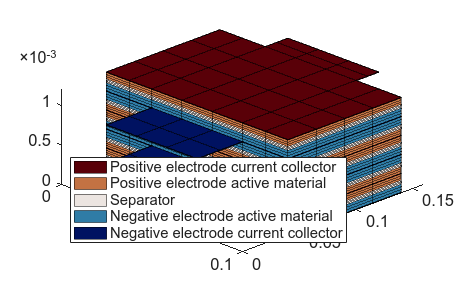

In [10]:
% make the axis tight and set the camera viewing angle
axis tight
view(45,45)

## Run the simulation

In [11]:
output = runBattery(jsonstruct);


## Visualize the Results

extract the time and voltage quantities


In [12]:
states = output.states;

time    = cellfun(@(state) state.time, states);
voltage = cellfun(@(state) state.('Control').E, states);


We plot the discharge curves together in a new figure



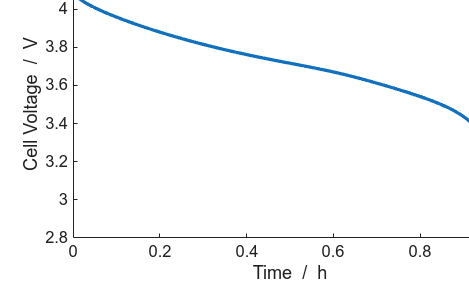

In [13]:
figure();
plot((time/hour), voltage, '-', 'linewidth', 3)
xlabel('Time  /  h')
ylabel('Cell Voltage  /  V')
title('Voltage');


For a given time step, we plot the concentration on the grid.



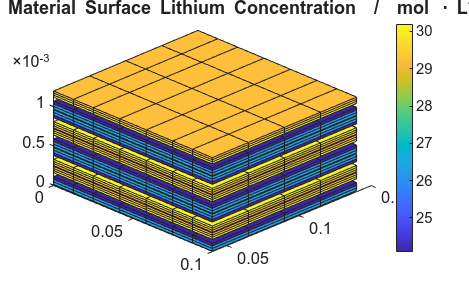

In [14]:
% Set the timestep we want to visualize
timestep = 20;

% get the state of the simulation at the given timestep
state = states{timestep};

% create a new figure
figure()

% plot the surface concentration of lithium in the negative electrode active material
plotCellData(model.NegativeElectrode.Coating.grid, state.NegativeElectrode.Coating.ActiveMaterial.SolidDiffusion.cSurface/(mol/litre))

% plot the surface concentration of lithium in the positive electrode active material
plotCellData(model.PositiveElectrode.Coating.grid, state.PositiveElectrode.Coating.ActiveMaterial.SolidDiffusion.cSurface/(mol/litre))

title('Active Material Surface Lithium Concentration  /  mol \cdot L^{-1}');
% add a colorbar
colorbar()
view(45,45)

In [15]:

%{
Copyright 2021-2026 SINTEF Industry, Sustainable Energy Technology
and SINTEF Digital, Mathematics & Cybernetics.

This file is part of The Battery Modeling Toolbox BattMo

BattMo is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

BattMo is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with BattMo.  If not, see <http://www.gnu.org/licenses/>.
%}